<div style="text-align: center; padding-top: 12%;">

# Supervised Machine Learning: Linear Regression

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%201.3%20-%20Supervised_Learning_Linear_Regression.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

> How can we predict a continuous quantity, and what if the relationship isn't linear?

# <font color='blue' size=5pt> Revisit - Tests for Normality </font>

Why check residual normality? Normality of the errors is mainly important for classical statistical inference, such as confidence intervals and hypothesis tests for regression coefficients. It is not required for computing the OLS estimates themselves.

##  <font color='blue'> What is a Normality Test? </font>

Assume we have a univariate set of values ( we have a sample from a univariate distribution.) We are checking, based on some calculations with the sample data, if the univariate distribution is a normal one.

**Main Idea**: Normality can be assessed by comparing the empirical distribution of the residuals with the theoretical normal distribution.

We want to recast this matching procedure onto the backdrop of a linear correlation situation; this means we want to compare the two cumulative distribution functions. To explain, we want the empirical percentiles to correlate linearly with the theoretical percentiles of a standard normal distribution.



## <font color='blue'> Revisit - The Kolmogorov-Smirnov test </font>

The Kolmogorov-Smirnov test uses the concept of cummulative distribution functions:

$$CDF(x):= P(X<x) = \int_{-∞}^{x}f(t)dt$$

The concept is useful in applications where we want to check if a random variable follows a certain distribution.

IMPORTANT: In most cases we standardize the values of the random variable, e.g we compute z-scores.

The test is defined as:

  **H0 (the null hypothesis):**	The data follow a specified distribution.

  **H1 (the alternative hypothesis):** The data do not follow the specified distribution

The main idea is that we focus on how much the empirical cummulative distribution function is different from the theoretical cummulative distribution function, and we may consider:

$$\sup_{x} |ECDF(x) - CDF(x)|$$

where $\text{ECDF}(x)$ means the emprirical cummulative distribution function:

$$ ECDF(x):= \frac{1}{n}\sum \mathbb{1}(t)_{t<x} $$

and, $CDF$ stands for the cummulative distribution function:

$$CDF(x):= \int_{-\infty}^{x}f(t)dt.$$  Here $f$ is the probability density function.

If we order the observations, such as $x_i\leq x_j$ when $i\leq j$, then the test statistic is formally defined by:

$$D:=\max_{1\leq i\leq n}\left\{CDF(x_i)-\frac{i-1}{n},\frac{i}{n}-CDF(x_i)\right\}$$

The mathematical notation means that we add $1$ for each $t$ less than $x$ and $n$ represents the sample size.


If the p-value is high (much greater then 5%) we do not reject the null hypethesis which means that we do not find sufficient evidence to reject the normality assumption.

## <font color='blue'> Revisit - The Anderson-Darling Test</font>

The test is defined as:

  **H0 (the null hypothesis)**:	The data follow a specified distribution.

  **H1 (the alternative hypothesis)**: The data do not follow the specified distribution

  The test statistic is defined as:

  $$\large AD := -n - \sum_{i=1}^{n} \frac{2i-1}{n}\left[\ln(CDF(x_i))+\ln(1-CDF(x_{n+1-i})\right] $$

The critical values for the Anderson-Darling test are dependent on the specific distribution that is being tested.

# <font color='blue'> Revisit - Vector Spaces </font>

## Intuition

* A vector represents a way of encoding information in an organized way that allows also useful operations to be carried out.

* Building intuition: think of position vectors. The addition/subtraction operations can be carried out componentwise. Multiplication by scalars (e.g. real numbers) are also distributed to all of the vector's commponents.



<figure>
<center>
<img src='https://i.imgur.com/hL5eCrq.png'width='300px'/>
<figcaption>Vector Addition</figcaption></center>
</figure>


* Example: an array of prescribed dimensionality can be regarded as a vector.

* More abstract objects, such as continuous or integrable functions can be regarded as vectors, as well.

## Vector Spaces - Formal Definition

<font color='red' size =4pt>A vector space $V$ is a set whose elements can be multiplied with scalars and combined among themselves by using a $"\cdot"$ and a $"+"$ operation, respectively.  These operations mentioned above, must satisfy the following properties:</font>


| **Axiom**                                                                                                                                | **Meaning**                                                                                                                                                                                                  |
| ---------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| [Associativity](https://en.wikipedia.org/wiki/Associativity "Associativity") of vector addition                                          | **u** + (**v** + **w**) = (**u** + **v**) + **w**                                                                                                                                                            |
| [Commutativity](https://en.wikipedia.org/wiki/Commutativity "Commutativity") of vector addition                                          | **u** + **v** = **v** + **u**                                                                                                                                                                                |
| [Identity element](https://en.wikipedia.org/wiki/Identity_element "Identity element") of vector addition                                 | There exists an element **0**∈ _V_, called the _[zero vector](https://en.wikipedia.org/wiki/Zero_vector "Zero vector")_, such that **v** + **0** = **v** for all **v**∈ _V_.                                 |
| [Inverse elements](https://en.wikipedia.org/wiki/Inverse_element "Inverse element") of vector addition                                   | For every **v**∈ _V_, there exists an element −**v** ∈ _V_, called the _[additive inverse](https://en.wikipedia.org/wiki/Additive_inverse "Additive inverse")_ of **v**, such that **v** + (−**v**) = **0**. |
| Compatibility of scalar multiplication with field multiplication                                                                         | _a_(_b_**v**) = (_ab_)**v**<sup>[\[nb 3\]](https://en.wikipedia.org/wiki/Vector_space#cite_note-4)</sup>                                                                                                     |
| Identity element of scalar multiplication                                                                                                | 1**v** = **v**, where 1 denotes the [multiplicative identity](https://en.wikipedia.org/wiki/Multiplicative_identity "Multiplicative identity") in _F_.                                                       |
| [Distributivity](https://en.wikipedia.org/wiki/Distributivity "Distributivity") of scalar multiplication with respect to vector addition | _a_(**u** + **v**) = _a_**u** + _a_**v**                                                                                                                                                                     |
| Distributivity of scalar multiplication with respect to field addition                                                                   | (_a_ + _b_)**v** = _a_**v** + _b_**v**                                      

# <font color='blue' size=5pt>Revisit - Ordinary Least Squares Regression (OLS) (A Simplest Case)</font>

First, we assume the simplest case: data has only one input feature that is continuous.

The main idea of linear regression is the expected value of the output is a linear function of the input variable(s).

$$\mathbb{E}(Y|X=x)\approx m\cdot x + b$$

To determine the line of best fit the goal is to minimize the sum of squared residuals:

<font color='navy'>
$$
\min_{m,b} \sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$
</font>

So the sum of the squared residuals is

$$
\sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$

If $N$ represents the number of observations (the number of rows in the data) then the cost function may be defined
<font color='red'>
$$
L(m,b) = \frac{1}{N} \sum\limits_{i=1}^{N}(y_i-mx_i-b)^2
$$</font>

where

$$\hat{y_i} = m_\cdot x_i +b.$$

If we get our predictions $\hat{y}_i$ then we have that the Mean Squared Error is

$$
\frac{1}{N} \sum\limits_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

<font color='forestgreen'> Critical Thinking: at the optimal values $(m,b)$ the partial derivatives of the cost function $L$ are equal to 0.</font>

The <font color='deepskyblue'>*gradient descent algorithm*</font> is based on this idea.


Thus, the equation of the best fit line is $$\hat{y} = mx + b.$$

<font color='red'> CRITICAL THINKING: How *exactly* are we obtaining the slope and the intercept?</font>

<font color='forestgreen'>ANSWER: One way to obtain the slope and the intercept is by applying the *Ordinary Least Squares* method.</font>

We determine the values of <font color='blue'>$m$</font> and <font color='red'>$b$</font> such that the sum of the square distances between the points and the line is *minimal*.</font>

An example of a loss function with two coefficients is

$$L(w_1,w_2): = \frac{1}{n}\sum (y_i - w_1\cdot x_{i1} - w_2\cdot x_{i2})^2$$

Here we have a vector $$\vec{w}:=(w_1,w_2)$$

We can think of the vector $\vec{w}$ having (in this case) two components and a perturbation of $\vec{w}$ in some direction such as $\vec{v}.$

We consider the function $g(t):=L(\vec{w}+t\cdot \vec{v})$ we get some important ideas:

i. if $\vec{w}$ is ideal for the cost then $t=0$ is min of the function $g$ and so $g'(0)=0.$

ii. if $\vec{w}$ is not minimizing the cost then we want to decrease the function $g$

Here we have that $$g'(t):= \nabla L \cdot \vec{v}$$ should be negative (because we want to decrease $g$) and we get a good outcome if

$$\vec{v}:= - \nabla L$$

This means that the coefficients should be updated in the negative direction of the gradient, such as:

$$ \vec{w}_{new} := \vec{w}_{old} - \text{lr}\cdot\nabla L$$

where "lr" stands for "learning rate."

<figure>
<center>
<img src='https://i.imgur.com/KzUuU3q.gif'width='650px'/>
<figcaption>Gradient Descent Animation</figcaption></center>
</figure>

<figure>
<center>
<img src='https://i.imgur.com/6S1weRY.gif'
width='600px' />
<figcaption>Source: Simple Linear Regression (Tobias Roeschl)</figcaption></center>
</figure>



# <font color='blue'> Introduction to Regression </font>

**From Optimization to Prediction:**  
In the previous lectures, we learned how **Gradient Descent (GD)** minimizes a loss function. We now apply GD to a fundamental supervised learning problem: **regression**.

**Main Idea:**
- The output (dependent) variable $y$ is **continuous**, and we want to predict its value from input features $X$, typically **within the range represented by the training data**.  
- Real data contain **noise**: similar input values may produce slightly different outputs, and measurements themselves may contain errors.
- We commonly model this as $y=f(X)+\epsilon$,  where $\epsilon$ represents noise/error, often assumed to follow a **normal distribution with mean $0$ and unknown standard deviation $\sigma$**.
- **Our goal:** learn $f(X)$ by minimizing prediction error — and **Gradient Descent provides a way to do this optimization**.

## <font color='blue'>From Simple to Multiple Linear Regression</font>

Recall our **study hours → exam score** example:
$$
\hat y_i = w_0 + w_1x_i
$$

For **all $n$ students at once**:
$$
\underbrace{\begin{bmatrix}
\hat y_1\\ \hat y_2\\ \vdots\\ \hat y_n
\end{bmatrix}}_{\hat{\mathbf y}}
=
\underbrace{\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}}_{\mathbf X}
\underbrace{\begin{bmatrix}
w_0\\w_1
\end{bmatrix}}_{\mathbf w}
\qquad\Longrightarrow\qquad
\boxed{\hat{\mathbf y}=\mathbf X\mathbf w}
$$

Now suppose we use **$p$ features** (study hours, attendance, previous GPA, ...):
$$
\boxed{
\mathbf X=
\begin{bmatrix}
1&x_{11}&\cdots&x_{1p}\\
1&x_{21}&\cdots&x_{2p}\\
\vdots&\vdots&&\vdots\\
1&x_{n1}&\cdots&x_{np}
\end{bmatrix},
\qquad
\mathbf w=
\begin{bmatrix}
w_0\\w_1\\ \vdots\\w_p
\end{bmatrix},
\qquad
\hat{\mathbf y}=\mathbf X\mathbf w
}
$$

**Key idea:** $\mathbf X\mathbf w$ is a **linear combination of the feature columns**:
$$
\hat{\mathbf y}
=w_0\mathbf 1+w_1\mathbf x_1+\cdots+w_p\mathbf x_p
$$

<font color='green'>Same linear model and same OLS objective — we simply extend from one feature to many features.</font>

## <font color='blue'>OLS Solution in Vector Form</font>

For multiple linear regression, we assume
$$
\mathbf y = \mathbf X\mathbf w + \boldsymbol{\epsilon},
\qquad
\mathbb E[\boldsymbol{\epsilon}]=\mathbf 0
$$
where $\mathbf X$ contains the input features, $\mathbf w$ is the vector of weights, and $\boldsymbol{\epsilon}$ represents i.i.d. noise (often $\boldsymbol{\epsilon}\sim N(\mathbf 0,\sigma^2\mathbf I)$).

Our prediction is $\hat{\mathbf y}=\mathbf X\mathbf w$

so the **OLS loss** is the sum of squared residuals:
$$
L(\mathbf w)
=\|\mathbf y-\mathbf X\mathbf w\|_2^2
=(\mathbf y-\mathbf X\mathbf w)^T(\mathbf y-\mathbf X\mathbf w)
$$

To find the optimal weights, set the gradient to zero:
$$
\nabla_{\mathbf w}L
=-2\mathbf X^T(\mathbf y-\mathbf X\mathbf w)=\mathbf 0
$$

which gives the **normal equation** if $\mathbf X^T\mathbf X$ is invertible
$$
\boxed{
\hat{\mathbf w}
=(\mathbf X^T\mathbf X)^{-1}\mathbf X^T\mathbf y
}
$$

<font color='green'>Thus, OLS gives the weights that minimize the squared prediction error. Gradient Descent provides another way to find these optimal weights without explicitly computing the inverse.</font>

# <font color='blue'>Linear vs. Nonlinear Models: What Does "Linear" Mean?</font>

So far, we have used **linear regression**:
$$
\large
\hat y = w_0+w_1x_1+w_2x_2+\cdots+w_px_p
$$

<font color='green'>**Linear regression is linear in the weights $w$.**</font>  
Each weight appears only to the **first power** and weights are not multiplied, divided, or transformed.

For example,
$$
\hat y=w_0+w_1x_1+w_2x_2-w_3x_3
\qquad \text{is linear in } w.
$$

But a model such as
$$
\large
\hat y=w_0+w_1^3x_1+\frac{1}{w_2+w_3}x_2-e^{w_3}x_3
$$
is **nonlinear in the weights**.

## <font color='darkgreen'>Why does this matter?</font>

For linear regression with squared-error loss,

$$
\boxed{\hat{\mathbf w}=(X^TX)^{-1}X^T\mathbf y}
$$

gives the OLS solution (when $X^TX$ is invertible).

For a **nonlinear regression model**, such a closed-form solution generally does not exist:

$$
\boxed{
\hat{\mathbf w}
=\arg\min_{\mathbf w}
\sum_{i=1}^n
\left(y_i-f(\mathbf x_i;\mathbf w)\right)^2
}
$$

<font color='magenta'>This brings us back to Gradient Descent: we can iteratively learn $\mathbf w$ even when we cannot solve for it directly.</font>

# <font color='blue'>Polynomial Regression</font>

<font color='slateblue'>**Main idea:** Model a nonlinear relationship by using different powers of the input feature as new features.</font>

For one feature $x$, a polynomial model of degree $p$ is $ \hat y= w_0+w_1x+w_2x^2+\cdots+w_px^p $.

For example, a **cubic regression model** is $\hat y=w_0+w_1x+w_2x^2+w_3x^3$

**IMPORTANT:** The model is **nonlinear in $x$**, but still **linear in the weights** $w_0,\ldots,w_p$:
$$
\hat y
=
\underbrace{
\begin{bmatrix}
1&x&x^2&\cdots&x^p
\end{bmatrix}}_{\text{transformed features}}
\underbrace{
\begin{bmatrix}
w_0\\w_1\\w_2\\\vdots\\w_p
\end{bmatrix}}_{\mathbf w}
$$

Therefore, polynomial regression is still a **linear model in its parameters**, and we can use the same OLS framework: ${\hat{\mathbf y}=X_{\text{poly}}\mathbf w}$.

<span style="color:green;font-size:14pt">Critical Thinking</span>
**What does a cubic polynomial regression model with two input features $x_1$ and $x_2$ look like?**

## Polynomials in one variable

<font color='slateblue'> Main idea: Linear combination of different powers of the feature values.

$$\large
P(x):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

What we hope to achieve:

$$\large \mathbb{E}(Y|X=x)\approx \beta_p x^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0$$

IMPORTANT: P(x) is nonlinear in x. However if x is fixed (x is your data) and $\beta$ is the input we have
$$\large
L(\beta):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

is linear in $\beta=(\beta_0,\beta_1,\beta_2,...\beta_p).$

$$\large L(\beta+\gamma)= L(\beta)+L(\gamma)$$

and

$$\large L(c\cdot \beta) = c\cdot L(\beta)$$

for any two vectors $\beta$ and $\gamma$, and any scalar (real number) $c.$


# <font color='blue' > Error Metrics </font>

## <font color='blue'> MSE </font>
Mean squared error:
$$\text{MSE}:=\frac{1}{n}\sum_{i=1}^{n}(y_i-x_i\cdot\vec{w})^2$$

here the i-th observation has multiple features:

$$x_i = \left(x_{i0},x_{i1},...x_{ip}\right)$$ with $x_{i0}$ as the added 1s column.

where the "dot" product is defined as

$$x_i\cdot\vec{w} = \sum_{j=0}^{p} x_{ij}w_j$$

## <font color='blue'> RMSE

Root mean squared error:

$$\text{RMSE}:=\left(\frac{1}{n}\sum_{i=1}^{n}(y_i-x_i\cdot\vec{w})^2\right)^{1/2}$$

## <font color='blue'> MAE

Mean absolute error:

$$\text{MAE}:=\frac{1}{n}\sum_{i=1}^{n}\left|y_i-x_i\cdot\vec{w}\right|$$

Is a small error enough to conclude that we have a good regression model?

# <font color='blue'>Diagnostics for Regression: How Good Is Our Model?</font>

Recall that regression (linear, non-linear, polynomial etc.) aims to approximate the **conditional mean**:

$$
\large
\mathbb E[Y\mid X=x]=f(x),
\qquad
Y=f(X)+\epsilon
$$

where the error is commonly modeled as

$$
\epsilon_i\overset{iid}{\sim}N(0,\sigma^2).
$$

After learning $\hat f$, each prediction has a **residual**

$$
e_i=y_i-\hat y_i.
$$

## <font color='blue'>Residual Diagnostics: What Should the Errors Look Like?</font>
If the model captures the systematic relationship between $X$ and $Y$, the residuals should look mostly like **random noise**.

<font color='green'>What do we want to see?</font>
- **Centered around 0:** no systematic over- or under-prediction.
- **No systematic pattern:** a curve or trend may indicate that the model misses part of the relationship.
- **Roughly constant spread:** the variability of residuals should not systematically increase or decrease with $\hat y$.
- **Approximately normal errors:** mainly important when performing classical statistical inference (e.g., confidence intervals and hypothesis tests).

A common diagnostic is to plot
$$
\boxed{\text{Residuals } e_i \quad \text{vs.} \quad \text{Predicted values } \hat y_i}
$$

<font color='green'>
Good: residuals are randomly scattered around 0 with roughly constant spread.
</font>

<font color='red'>
Warning signs: curves, trends, clusters
    </font>

## <font color='blue'>Coefficient of Determination: $R^2$</font>

A common measure of how well the model explains variation in $Y$ is
$$
\boxed{
R^2
=1-\frac{\displaystyle\sum_{i=1}^n(y_i-\hat y_i)^2}
{\displaystyle\sum_{i=1}^n(y_i-\bar y)^2}
=1-\frac{\text{RSS}}{\text{TSS}}
}
$$
- RSS — Residual Sum of Squares measures the prediction errors of your regression model
- TSS — Total Sum of Squares measures the total variation of $y$ around its mean

**Interpretation:**

- $R^2=1$: predictions perfectly fit the observed data.
- $R^2\approx0$: the model explains little more variation than predicting $\bar y$.
- $R^2<0$: the model can perform worse than simply predicting $\bar y$.

<font color='red'>**Important:** A high $R^2$ does not necessarily mean a good predictive model — adding more features can increase $R^2$ and may lead to **overfitting**.</font>

<span style="color:green;font-size:14pt">Critical Thinking</span>
**If increasing the polynomial degree always increases (or maintains) training $R^2$, should we simply choose the model with the highest $R^2$?**

## <font color='blue'>Correlation and Statistical Significance</font>

### <font color='blue'>Pearson Correlation Coefficient</font>

Pearson's $r$ measures the **strength and direction of a linear relationship** between two variables:
$$
\large
r=
\frac{1}{n-1}\sum_{i=1}^{n}
\underbrace{\left(\frac{x_i-\bar{x}}{s_x}\right)}_{\text{standardized }x_i}
\underbrace{\left(\frac{y_i-\bar{y}}{s_y}\right)}_{\text{standardized }y_i},
\qquad -1\le r\le1
$$
where $s_x$ and $s_y$ are the **sample standard deviations** of $X$ and $Y$.

### <font color='green'>Connection to What We Learned Before</font>

Recall the **standard score (z-score)**:
$$
z=\frac{x-\bar{x}}{s}
$$

Thus, Pearson's $r$ is essentially the **average product of the standardized values** of $X$ and $Y$. Equivalently,
$$
\boxed{r=
\frac{1}{n-1}\sum_{i=1}^{n}
\underbrace{\left(\frac{x_i-\bar{x}}{s_x}\right)}_{\text{standardized }x_i}
\underbrace{\left(\frac{y_i-\bar{y}}{s_y}\right)}_{\text{standardized }y_i}
=\frac{\operatorname{Cov}(X,Y)}{s_xs_y}, \qquad -1\le r\le1}
$$

Therefore:
- $r\approx1$: large $X$ tends to occur with large $Y$ $\rightarrow$ strong positive linear relationship
- $r\approx-1$: large $X$ tends to occur with small $Y$ $\rightarrow$ strong negative linear relationship
- $r\approx0$: little or no **linear** relationship

<font color='red'>**Correlation does not imply causation, and $r\approx0$ does not imply no relationship — the relationship may be nonlinear.**</font>

### <font color='blue'>Is the Correlation Statistically Significant?</font>

The sample correlation $r$ may be nonzero **just because of random sampling**. We test whether there is evidence of a linear relationship in the population:
$$
H_0:\rho=0
\quad\text{(no population linear correlation)}
$$
$$
H_1:\rho\neq0
\quad\text{(population linear correlation exists)}
$$

where $\rho$ is the **population correlation** and $r$ is the correlation observed in our sample.

The $p$-value asks:
> **If $\rho=0$, how likely are we to observe a test statistic at least this extreme?**
- **Small $p$-value** $\rightarrow$ observed $r$ would be unusual under $H_0$ $\rightarrow$ evidence against $H_0$.
- **Large $p$-value** $\rightarrow$ observed $r$ is plausible under $H_0$ $\rightarrow$ insufficient evidence that $\rho\neq0$.

$$
\boxed{
r\ \longrightarrow\ t_{\text{obs}}=\frac{r\sqrt{n-2}}{\sqrt{1-r^2}}\ \longrightarrow\ t_{n-2}\ \longrightarrow\ p\text{-value}
}
$$

<font color='green'>Step 1: Transform $r$ into a test statistic</font>
The same $r$ is more convincing with a larger sample, so we account for the sample size $n$:
$$
\large
\boxed{
t_{\text{obs}}=\frac{r\sqrt{n-2}}{\sqrt{1-r^2}}
}
$$

<font color='green'>Step 2: Compare with the $t$-distribution</font>
If $H_0$ is true (with the usual assumptions),
$$
\boxed{T\sim t_{n-2}}
$$
so we know what values of $T$ would be expected **if the true correlation were zero**.

<font color='green'>Step 3: Compute the $p$-value</font>
For the two-sided test,
$$
\boxed{
p=P\left(|T|\ge |t_{\text{obs}}|\mid H_0\right)
}
$$

For the classical Pearson correlation $t$-test, the "usual assumptions" mainly mean:
- Paired quantitative data: each observation is a pair $(x_i,y_i)$.
- Independent observations: the pairs $(x_i,y_i)$ are independent across $i$.
- Linear relationship: Pearson $r$ is testing a linear association.
- No severe/influential outliers: Pearson $r$ can be strongly affected by outliers.
- Bivariate normality: for the exact small-sample $t$-test, $(X,Y)$ are assumed to follow a bivariate normal distribution.

### <font color='blue'>Connection to Simple Linear Regression</font>

**Correlation and simple linear regression describe the same linear relationship from different perspectives.**

For OLS simple linear regression,
$$
\hat y=\hat w_0+\hat w_1x,
$$

the slope is related to Pearson correlation by
$$
\boxed{\hat w_1=r\frac{s_y}{s_x}}
$$

where $r$ gives the **direction and strength** of the linear relationship, and $s_y/s_x$ converts it to the original units.

> For example, if $r=0.8$, $s_x=2$ hours, and $s_y=10$ points, $\hat w_1=0.8\frac{10}{2}=4$, so one additional study hour is associated with an estimated **4-point increase in score**.

For simple OLS regression with an intercept,
$$
\boxed{R^2=r^2}
$$

Thus,
$$
r=0.8 \quad\Rightarrow\quad R^2=0.64,
$$

meaning the fitted linear model explains **64% of the observed variation in $Y$**.

<font color='green'>
    

## Comparison
- **$r$:** How strongly and in what direction are $X$ and $Y$ linearly associated?
- **Regression:** What line can we use to predict $Y$ from $X$?
- **$R^2$:** How much of the variation in $Y$ is explained by the fitted line?
</font>

#### <font color='blue'>More Detailed Deduction</font>

**Correlation and simple linear regression describe the same linear relationship from different perspectives.**

For the OLS simple linear regression model

$$
\hat y=\hat w_0+\hat w_1x,
$$

the estimated slope is

$$
\boxed{\hat w_1=r\frac{s_y}{s_x}}
$$

where $r$ measures the **direction and strength** of the linear relationship, while $\frac{s_y}{s_x}$ converts that relationship back to the original units of $X$ and $Y$.

Therefore:

$$
r>0\Rightarrow\hat w_1>0,\qquad
r<0\Rightarrow\hat w_1<0,\qquad
r=0\Rightarrow\hat w_1=0.
$$

For example, if $r=0.8$, $s_x=2$ hours, and $s_y=10$ points,

$$
\hat w_1=0.8\frac{10}{2}=4,
$$

meaning **one additional study hour is associated with an estimated 4-point increase in score**.

---

For OLS simple linear regression **with an intercept**, there is another important relationship:

$$
\boxed{R^2=r^2}
$$

Why the square?

- $r$ gives the **direction and strength** of the linear association.
- $R^2$ measures the **proportion of variation in $Y$ explained by the fitted linear model** and is therefore nonnegative in this setting.

For example,

$$
r=0.8
\quad\Longrightarrow\quad
R^2=(0.8)^2=0.64.
$$

Thus, **64\% of the observed variation in $Y$ is explained by the fitted linear relationship with $X$**.

<font color='green'>
<b>Correlation:</b> How strongly are $X$ and $Y$ linearly associated?<br>
<b>Regression:</b> What line should we use to model/predict $Y$ from $X$?<br>
<b>$R^2$:</b> How much of the variation in $Y$ is explained by that fitted line?
</font>

#### <font color='blue'>More In-Depth: Why is the OLS Slope Related to Pearson Correlation?</font>

For **simple linear regression**, our prediction is

$$
\hat y_i=w_0+w_1x_i.
$$

OLS chooses $w_0$ and $w_1$ to minimize the **sum of squared residuals**:

$$
L(w_0,w_1)
=
\sum_{i=1}^n
\left(y_i-w_0-w_1x_i\right)^2.
$$

##### <font color='green'>Step 1: Minimize the OLS Loss</font>

Take the partial derivatives and set them equal to zero:

$$
\frac{\partial L}{\partial w_0}
=
-2\sum_{i=1}^n
(y_i-w_0-w_1x_i)=0,
$$

$$
\frac{\partial L}{\partial w_1}
=
-2\sum_{i=1}^n
x_i(y_i-w_0-w_1x_i)=0.
$$

From the first equation,

$$
\sum_{i=1}^n y_i
=
nw_0+w_1\sum_{i=1}^n x_i,
$$

so

$$
\boxed{
\hat w_0=\bar y-\hat w_1\bar x
}.
$$

Therefore, the OLS regression line always passes through

$$
\boxed{(\bar x,\bar y)}.
$$

Substituting $\hat w_0=\bar y-\hat w_1\bar x$ into the second equation and simplifying gives

$$
\boxed{
\hat w_1=
\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}
{\sum_{i=1}^n(x_i-\bar x)^2}
}.
$$

---

##### <font color='green'>Step 2: Connect the OLS Slope to Pearson $r$</font>

Recall that Pearson's correlation is

$$
r=
\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}
{(n-1)s_xs_y}.
$$

Therefore,

$$
\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)
=
(n-1)rs_xs_y.
$$

Also, from the definition of the sample variance,

$$
s_x^2=
\frac{1}{n-1}
\sum_{i=1}^n(x_i-\bar x)^2,
$$

so

$$
\sum_{i=1}^n(x_i-\bar x)^2
=
(n-1)s_x^2.
$$

Substituting these into the OLS slope,

$$
\hat w_1
=
\frac{(n-1)rs_xs_y}
{(n-1)s_x^2}
=
\boxed{
r\frac{s_y}{s_x}
}.
$$

#  <font color='blue' size=5pt> Code Applications </font>

---

In the following example we learn how to write a code in Python for determining the line of best fit given one dependent variable and one input feature. That is to say we are going to determine a slope  𝑚  and an intercept  𝑛 , the equation of the best fit line being  𝑦=𝑚𝑥+𝑏.

We are going to analyze a real data set that was extracted from the 1974 Motor Trend US magazine and comprises fuel consumption and 10 aspects of automobile design and performance for 32 automobiles (1973-1974 models).

## Setup

In [2]:
# Library Setup
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as MSE
from scipy.stats import pearsonr
from __future__ import print_function
from scipy.stats import kstest

## Data Import

In [23]:
# data
cars = pd.read_csv('https://github.com/yanhai-xiong/DATA301-AML/blob/main/Data%20Sets/mtcars.csv?raw=true')

In [24]:
cars.head(3)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


## **Objective 1**
We want to to know if there is any association between the weight of the car and the mileage.

In [25]:
cars['mpg'].values

array([21. , 21. , 22.8, 21.4, 18.7, 18.1, 14.3, 24.4, 22.8, 19.2, 17.8,
       16.4, 17.3, 15.2, 10.4, 10.4, 14.7, 32.4, 30.4, 33.9, 21.5, 15.5,
       15.2, 13.3, 19.2, 27.3, 26. , 30.4, 15.8, 19.7, 15. , 21.4])

In [26]:
y = cars.mpg.values
x = cars.wt.values

### Method 1 - Visualize with Plots

In [27]:
xb, yb = np.mean(x) , np.mean(y) # here we compute the center of mass

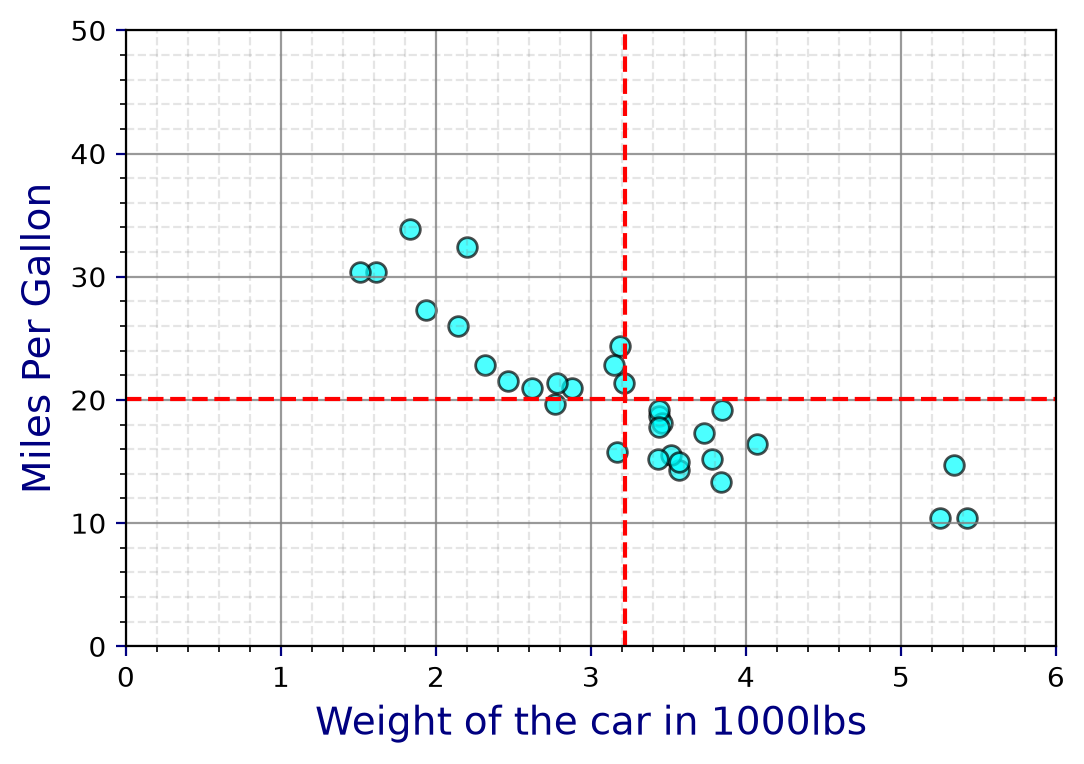

In [28]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y,color='cyan',s=50,ec='black',alpha=0.7)
ax.set_xlim(0, 6)
ax.set_ylim(0, 50)
ax.set_xlabel('Weight of the car in 1000lbs',fontsize=14,color='navy')
ax.set_ylabel('Miles Per Gallon',fontsize=14,color='navy')
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
plt.axvline(x=xb, color='red',linestyle='dashed')
plt.axhline(y=yb, color='red',linestyle='dashed')
plt.tick_params(axis='x', color='navy')
plt.tick_params(axis='y', color='navy')
ax.minorticks_on()
plt.show()

### <font color='blue'>Method 2 - Linear Regression with Scikit-learn</font>

Scikit-learn provides a built-in implementation of **Ordinary Least Squares (OLS) linear regression**:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
```

`fit(X, y)` learns the coefficients that minimize the **sum of squared residuals**:

$$
\boxed{
\min_{\mathbf w}\sum_{i=1}^n(y_i-\hat y_i)^2
}
$$

After training:

```python
model.intercept_      # learned intercept w_0
model.coef_           # learned weights w_1, ..., w_p
y_pred = model.predict(X)   # predictions
```

Thus, `LinearRegression` implements the same OLS regression we derived mathematically:

$$
\hat{\mathbf y}=X\hat{\mathbf w}.
$$

In [29]:
# here we make x a column vector or a matrix
# reshape: since scikit-learn expects the input X to be a 2D feature matrix
# x.reshape(-1,1): make 1 column and let NumPy automatically determine the number of rows
x = x.reshape(-1,1) #technical

In [30]:
model = LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-5.34]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,37.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.45]


In [32]:
x[0]

array([2.62])

In [69]:
m = model.coef_
b = model.intercept_

<bound method RegressorMixin.score of LinearRegression()>

In [40]:
print('The Slope is :'+str(m),' and the intercept is :' +str(b))

The Slope is :[-5.34447157]  and the intercept is :37.28512616734204


#### Contour Plots Example to Visualize Loss(m,b)

In [33]:
# this is a much simpler format of gradient descent if we only had one input feature and one intercept
def compute_cost(m,b):
    SSE = 0 # sum of squared error

    # number of datapoints in training data
    N = float(len(data))

    # Compute sum of squared errors
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        SSE += (y - (m * x + b)) ** 2

    # Return average of squared error
    return SSE/(2*N)

In [34]:
data = np.column_stack([x,y])

In [35]:
b_range = np.linspace(-120,120,num=4000)
m_range = np.linspace(-120,120,num=4000)
M, B = np.meshgrid(m_range, b_range)
Z = np.log10(compute_cost(M, B))

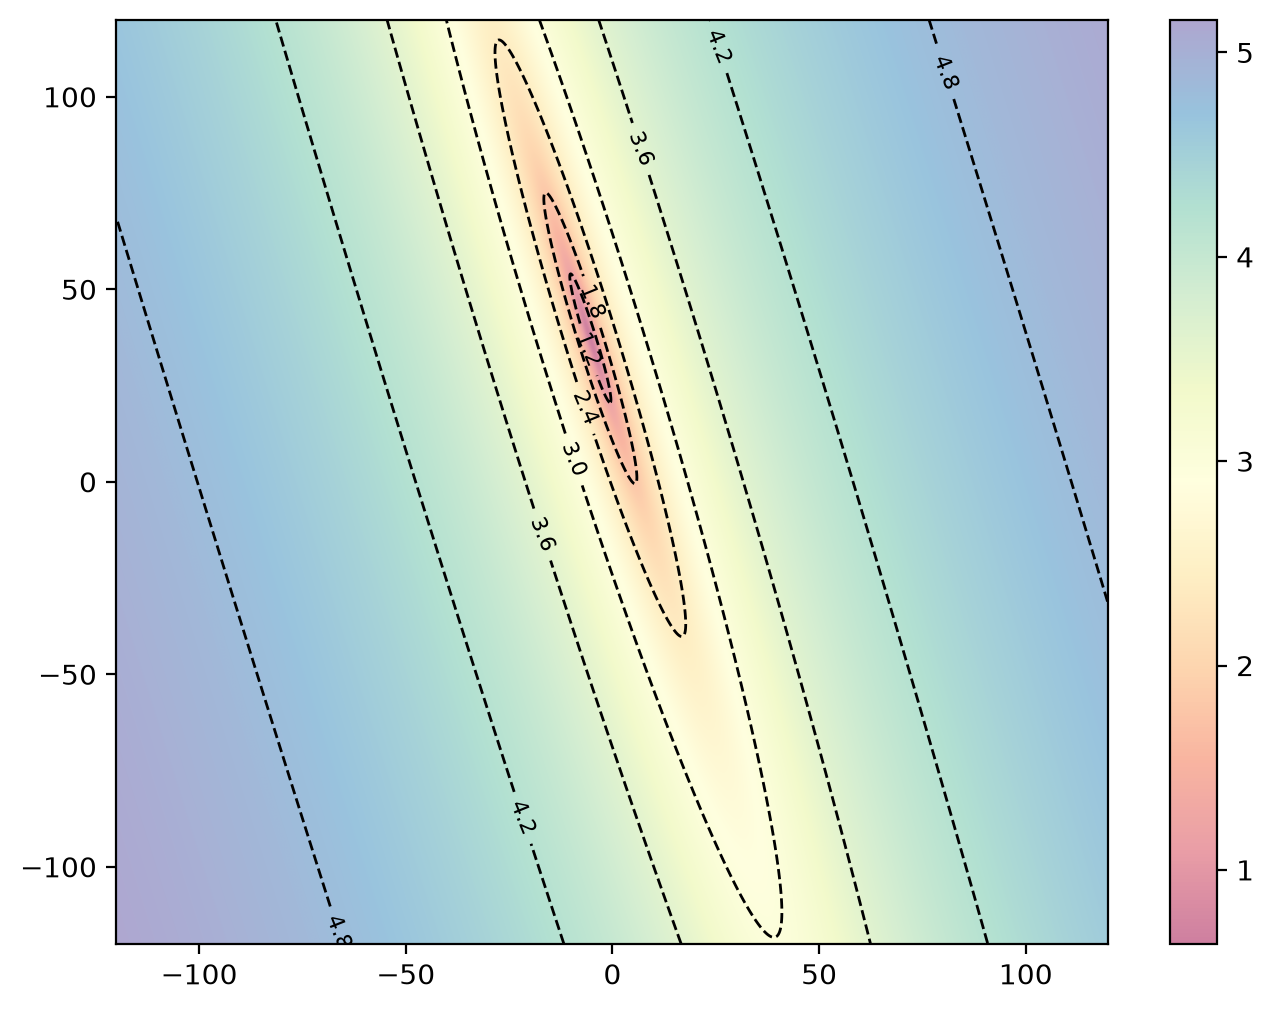

In [36]:
plt.figure(figsize=(8,6))
contours = plt.contour(M,B,Z,colors='black', linestyles='dashed', linewidths=1)
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[-120, 120, -120, 120], origin='lower',
           cmap='Spectral', alpha=0.5,aspect='auto', interpolation='bicubic')
plt.colorbar()
plt.show()

### Method 3 - Pearson's r

In [41]:
from scipy.stats import pearsonr

In [42]:
# we have to "ravel" back the x since scipy.stats.pearsonr(x, y) compares two 1D variables
x = x.ravel()

In [43]:
r, pval = pearsonr(x,y)
print('The correlation coefficient is :'+str(r)+'  and the pvalue for significance is :'+str(pval))

The correlation coefficient is :-0.8676593765172278  and the pvalue for significance is :1.293958701350513e-10


In [114]:
m_r = r*np.std(y)/np.std(x)

In [115]:
print('The slope of the trend calculated from r is :' +str(m_r))
print('The slope of the trend from linear regression is :' +str(m))

The slope of the trend calculated from r is :-0.694444372965317
The slope of the trend from linear regression is :[-5.34447157]


The equation of the line passing through the center of mass and that captires the trend is:
$$y-\bar{y} = m\cdot(x-\bar{x})$$

In short, $$y=m\cdot x + b$$ where $b = \bar{y} -m\cdot\bar{x}$

In [52]:
b_r = yb - m_r*xb
print('In our case the intercept derived from r is: ' +str(b_r)) # what is the meaning of the intercept?
print('In our case the intercept derived from linear regression is: ' +str(b)) # what is the meaning of the intercept?

In our case the intercept derived from r is: 37.285126167342035
In our case the intercept derived from linear regression is: 37.28512616734204


In [68]:
r**2

np.float64(0.7528327936582645)

In [70]:
model.score(x.reshape(-1,1),y)

0.7528327936582646

#### <font color='blue'> OLS Equivalence </font>

For simple linear regression with an intercept, the OLS slope can be computed from Pearson's correlation.

### Method 4 - Gradient Descent

In [61]:
def loss(b, m, data): # this is also called "loss" function
    total_cost = 0

    # number of datapoints in training data
    N = float(len(data))

    # Compute sum of squared errors
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        total_cost += (y - (m * x + b)) ** 2

    # Return average of squared error
    return total_cost/N

In [62]:
# this is the actual gradient descent
def step_gradient(b_current, m_current, data, eta):
    """takes one step down towards the minima

    Args:
        b_current (float): current value of b
        m_current (float): current value of m
        data (np.array): array containing the training data (x,y)
        eta (float): learning rate / step size

    Returns:
        tuple: (b,m) new values of b,m
    """

    m_gradient = 0
    b_gradient = 0
    N = float(len(data))

    # Calculate Gradient - assuming you know partial derivatives
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        m_gradient += - (2/N) * x * (y - (m_current * x + b_current)) # is the partial derivative with respect to m
        b_gradient += - (2/N) * (y - (m_current * x + b_current)) # is the partial derivative with respect to b

    # Update current m and b, eta stands for learning rate
    # we proceed in the direction of the negative gradient
    m_updated = m_current - eta * m_gradient
    b_updated = b_current - eta * b_gradient

    #Return updated parameters
    return b_updated, m_updated

def gradient_descent(data, starting_b, starting_m, learning_rate, num_iterations):
    """runs gradient descent

    Args:
        data (np.array): training data, containing x,y
        starting_b (float): initial value of b (random)
        starting_m (float): initial value of m (random)
        learning_rate (float): hyperparameter to adjust the step size during descent
        num_iterations (int): hyperparameter, decides the number of iterations for which gradient descent would run

    Returns:
        list : the first and second item are b, m respectively at which the best fit curve is obtained, the third and fourth items are two lists, which store the value of b,m as gradient descent proceeded.
    """

    # initial values
    b = starting_b
    m = starting_m

    # to store the cost after each iteration
    cost_graph = []

    # to store the value of b -> bias unit, m-> slope of line after each iteration (pred = m*x + b)
    b_progress = []
    m_progress = []

    # For every iteration, optimize b, m and compute its cost
    for i in range(num_iterations):
        cost_graph.append(loss(b, m, data))
        b, m = step_gradient(b, m, data, learning_rate)
        b_progress.append(b)
        m_progress.append(m)

    return [b, m, cost_graph,b_progress,m_progress]

In [63]:
#hyperparamters
learning_rate = 0.001
initial_b = 12
initial_m = 3
num_iterations = 50000
data = np.column_stack([x,y])

In [64]:
b, m, cost_graph,b_progress,m_progress = gradient_descent(data, initial_b, initial_m, learning_rate, num_iterations)

#Print optimized parameters
print ('Optimized b:', b)
print ('Optimized m:', m)

#Print error with optimized parameters
print ('Minimized cost:', loss(b, m, data))

Optimized b: 37.27234604666433
Optimized m: -5.340801130745784
Minimized cost: 8.697573986717137


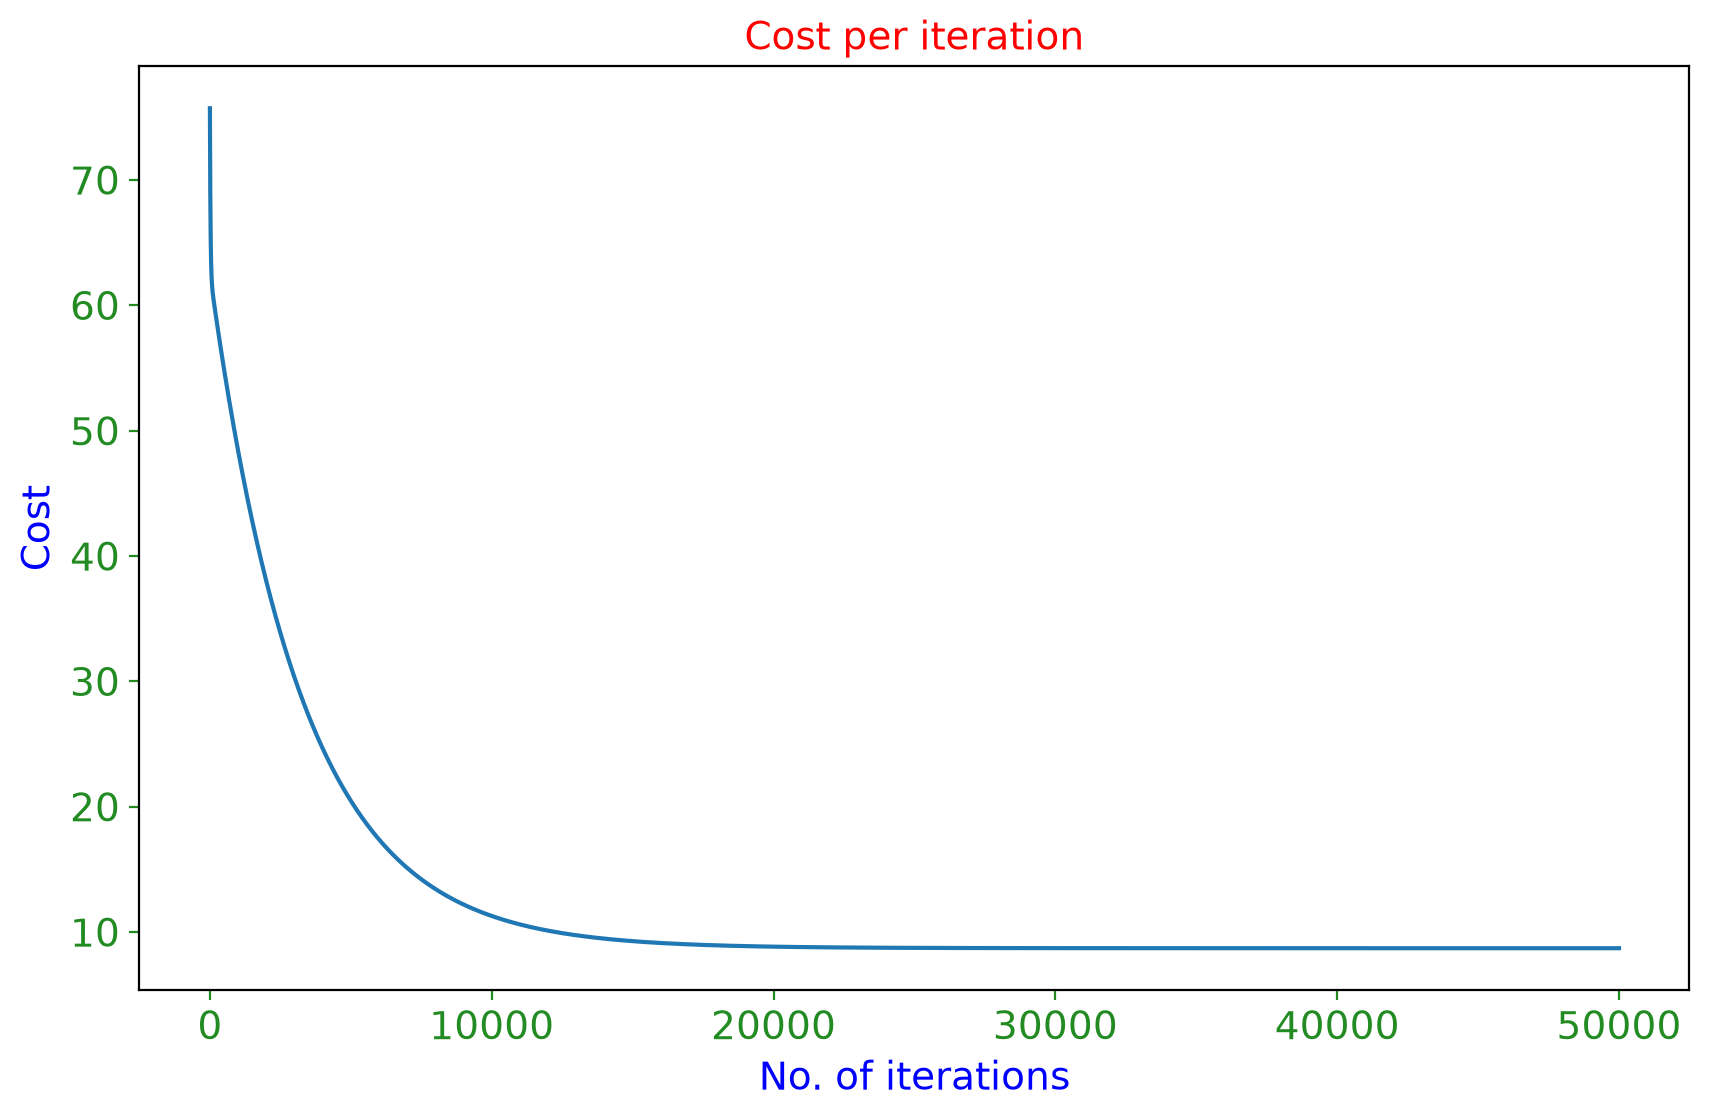

In [65]:
fig, ax = plt.subplots(figsize=(10,6))
plt.plot(cost_graph)
ax.set_xlabel('No. of iterations',fontsize=14,color='blue')
ax.set_ylabel('Cost',fontsize=14,color='blue')
plt.title('Cost per iteration',color='red',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax.tick_params(axis='x', colors='forestgreen')
ax.tick_params(axis='y', colors='forestgreen')
plt.show()

In [66]:
x_range = np.linspace(np.min(x)-1,np.max(x)+1,2)
yhat = model.predict(x_range.reshape(-1,1))

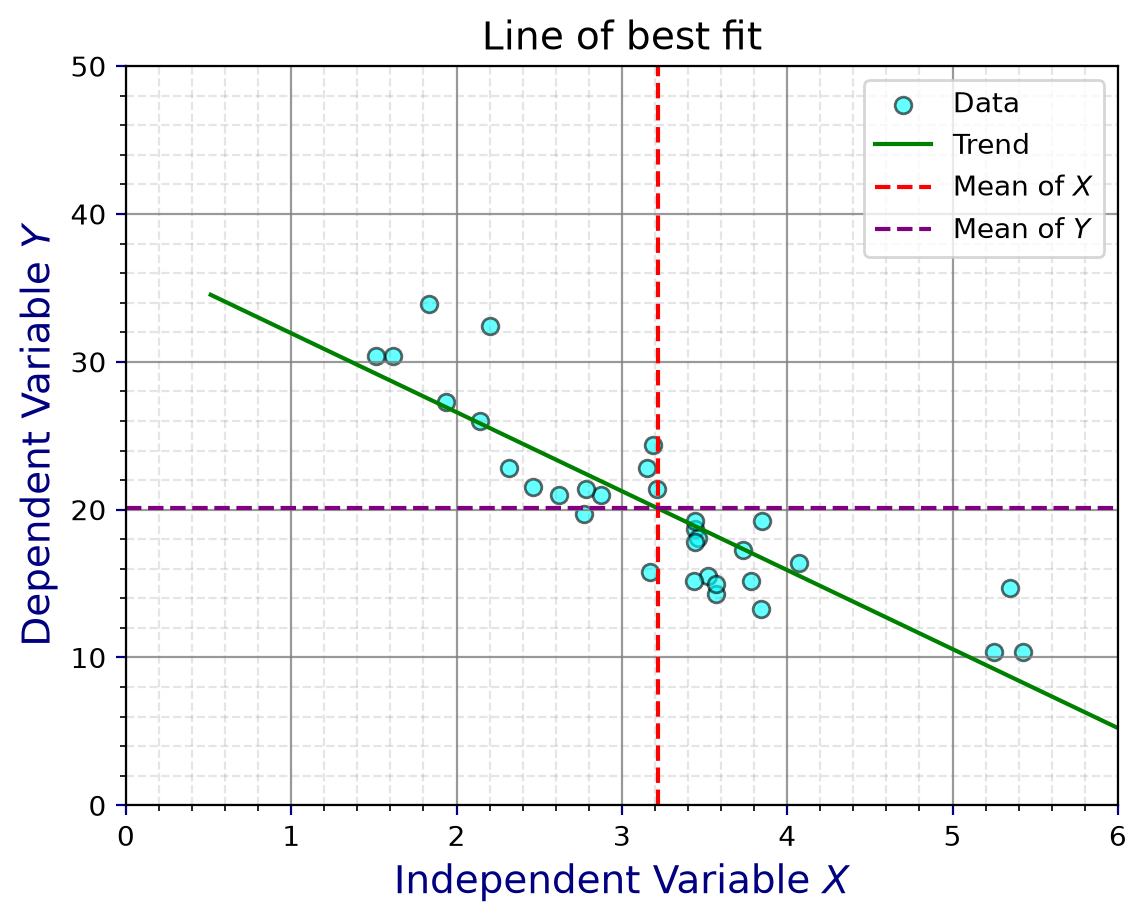

In [67]:
#Plot dataset
plt.scatter(x, y,ec='k',color='cyan',alpha=0.6)
#Predict y values
pred = m * x_range + b
#Plot predictions as line of best fit
plt.plot(x_range, pred, c='g')
plt.xlim(0, 6)
plt.ylim(0, 50)
plt.xlabel('Independent Variable $X$',fontsize=14,color='navy')
plt.ylabel('Dependent Variable $Y$',fontsize=14,color='navy')
plt.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
plt.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
plt.axvline(x=xb, color='red',linestyle='dashed')
plt.axhline(y=yb, color='purple',linestyle='dashed')
plt.tick_params(axis='x', color='navy')
plt.tick_params(axis='y', color='navy')
plt.minorticks_on()
plt.title('Line of best fit',fontsize=14)
plt.legend(['Data','Trend','Mean of $X$','Mean of $Y$'])
plt.savefig('lineacorrelation.png',dpi=300)
plt.show()

In [ ]:
r**2

0.7528327936582647

###   <font color='blue'>Test the Residuals for Goodness of fit for Method 2</font>

We investigate the distribution of the residuals, plot a histogram and apply a normality test

In [71]:
residuals = y - model.predict(x.reshape(-1,1))

In [72]:
import seaborn as sns

# import uniform distribution
from scipy import stats
from scipy.stats import norm

/var/folders/1m/2d5xq3d16t31xt6lgcqz8wlm0000gq/T/ipykernel_24077/2488235650.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(residuals,


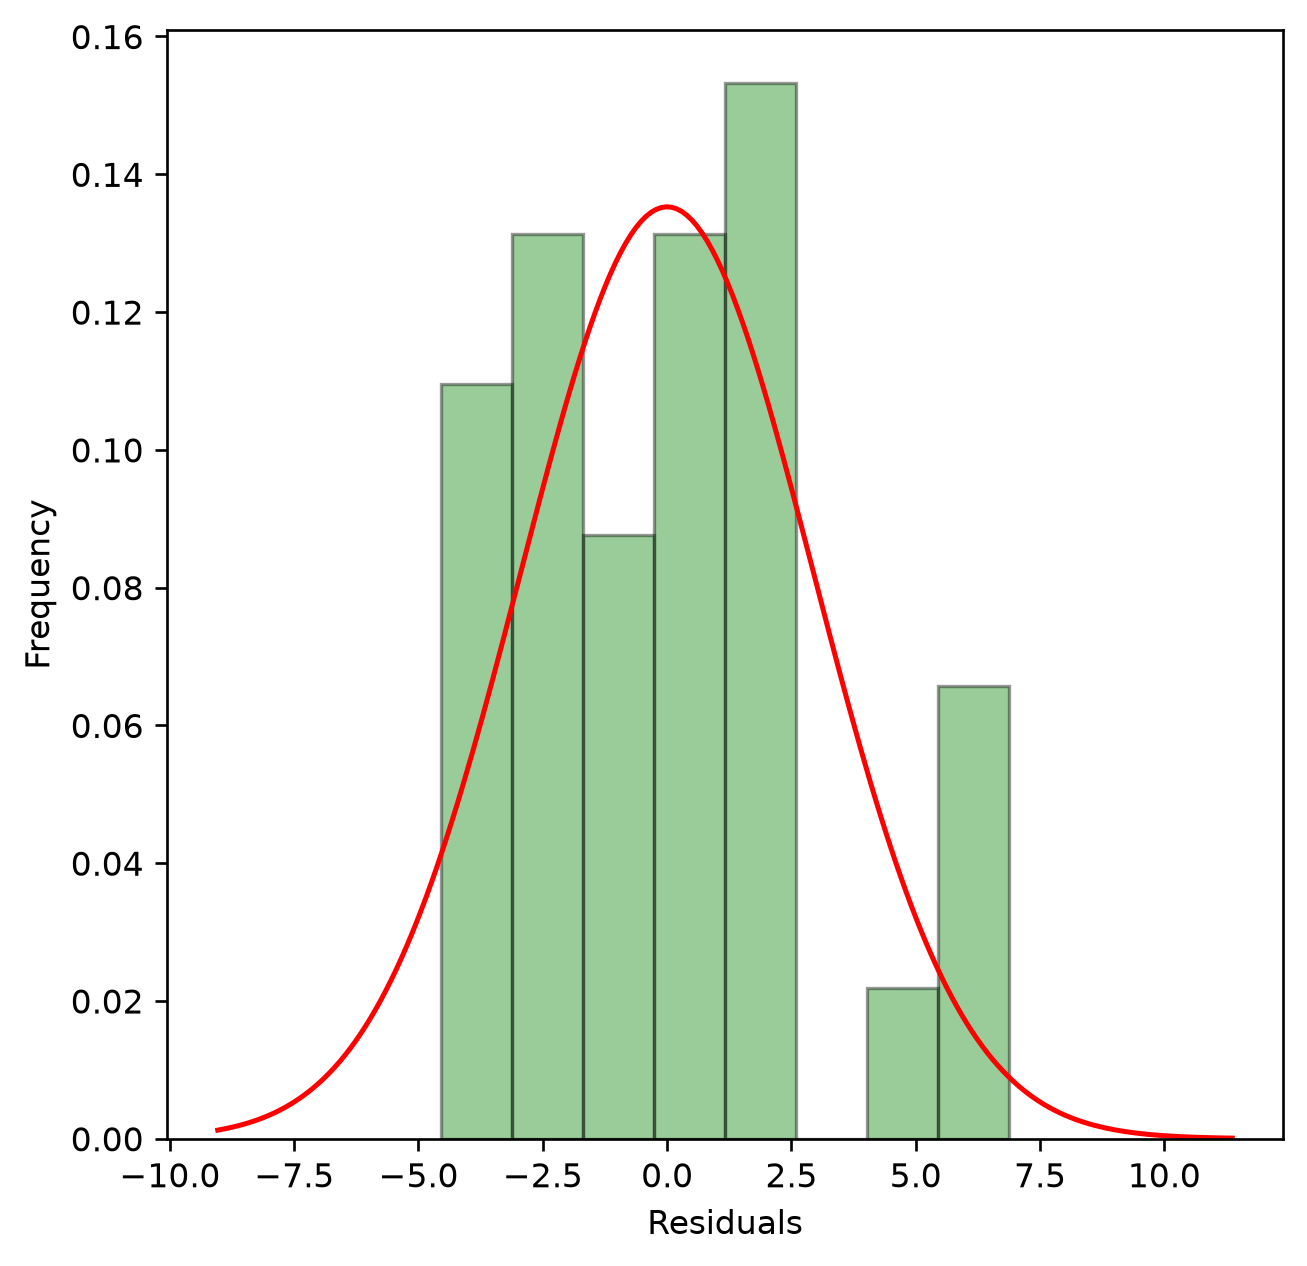

In [119]:
ax1 = sns.distplot(residuals,
                  bins=8,
                  kde=False,
                  color='deepskyblue',
                  hist_kws={"color":'green','ec':'black'},
                  fit=stats.norm,
                  fit_kws={"color":'red'})
ax1.set(xlabel='Residuals', ylabel='Frequency')
plt.show()

#### Normality Test

## <font color='blue'> Polynomial Regression</font>

<font color='slateblue'> Main idea: Linear combination of different powers of the feature values. </font>

$$\large
P(x):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

IMPORTANT: P(x) is nonlinear in x. However if x is fixed (x is your data) and $\beta$ is the input we have
$$\large
L(\beta):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

is linear in $\beta$


In [122]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

### Example in 1-D

$$\large p(x) = \frac{1}{4}x^3-\frac{3}{2}x^2+x$$

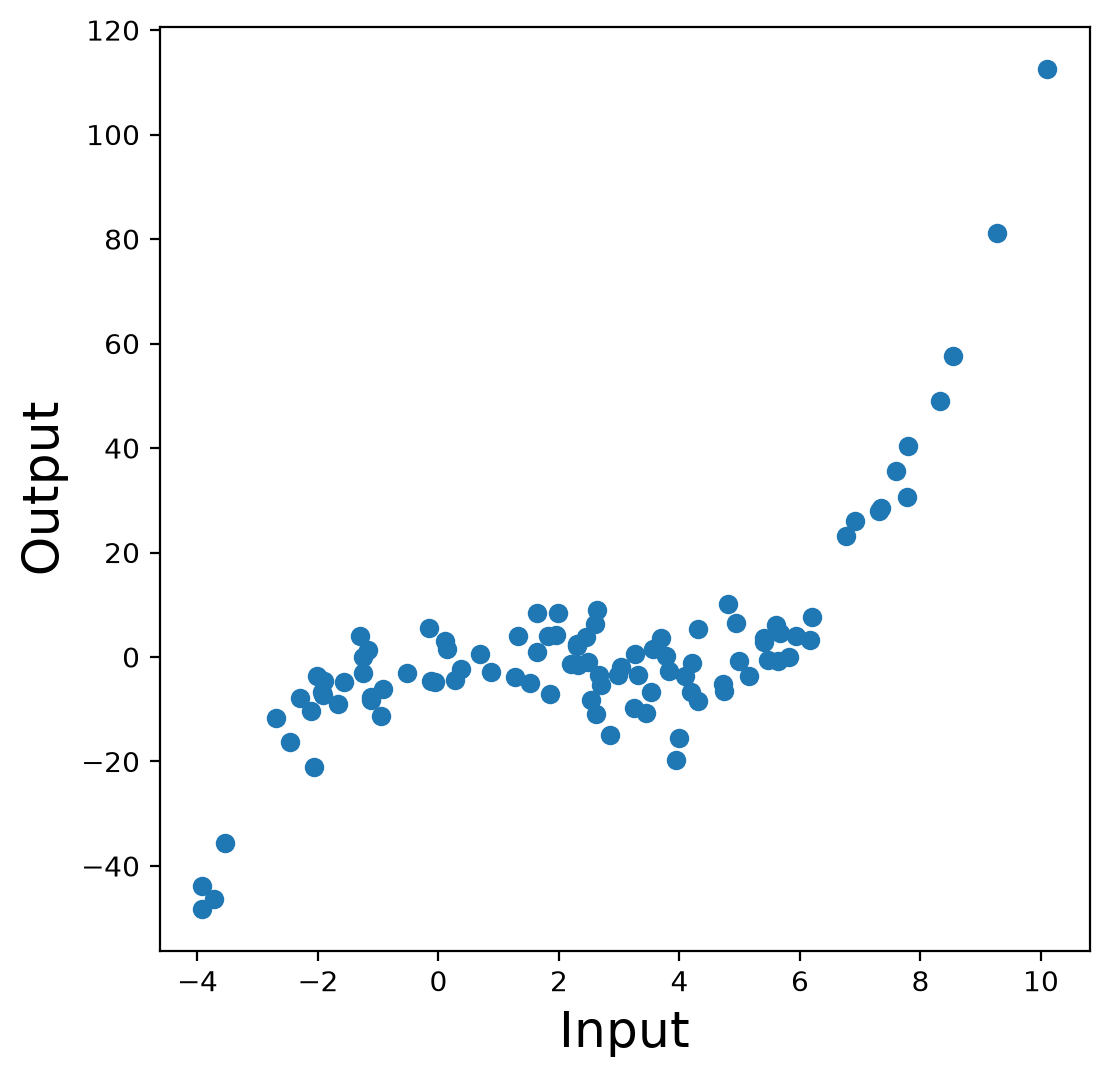

In [75]:
np.random.seed(1693)
x = 2 - 3 * np.random.normal(0, 1, 100) # this means non-equally spaced values
y = x - 1.5 * (x ** 2) + 0.25 * (x ** 3) + 5*np.random.normal(loc=0,scale=1,size=100) # we generate a cubic relationship between x and y
plt.figure(figsize=(6,6))
plt.scatter(x,y)
plt.xlabel('Input',fontsize=18)
plt.ylabel('Output',fontsize=18)
plt.show()

#### <font color='fuchsia'> Is a straight line a good idea for capturing the aspect?

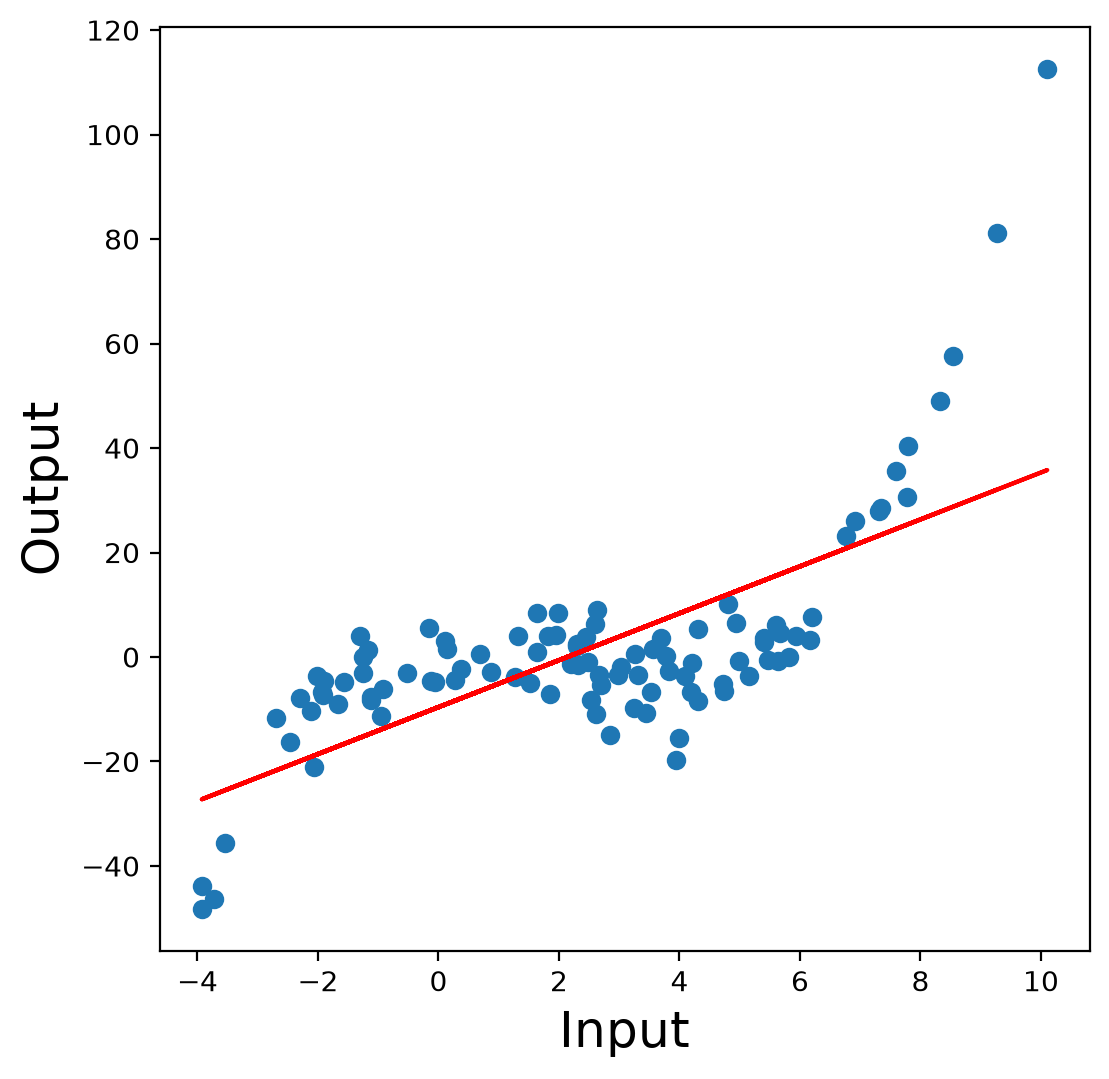

In [76]:
from sklearn import linear_model
lm = linear_model.LinearRegression()

model = lm.fit(x.reshape((-1,1)),y)
y_pred = lm.predict(x.reshape((-1,1)))
plt.figure(figsize=(6,6))
plt.scatter(x, y)
plt.plot(x, y_pred, '-',color='r')
plt.xlabel('Input',fontsize=18)
plt.ylabel('Output',fontsize=18)
plt.show()

#### Expand the features

In [77]:
import operator
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

5.369973037195502
0.9332479212313307


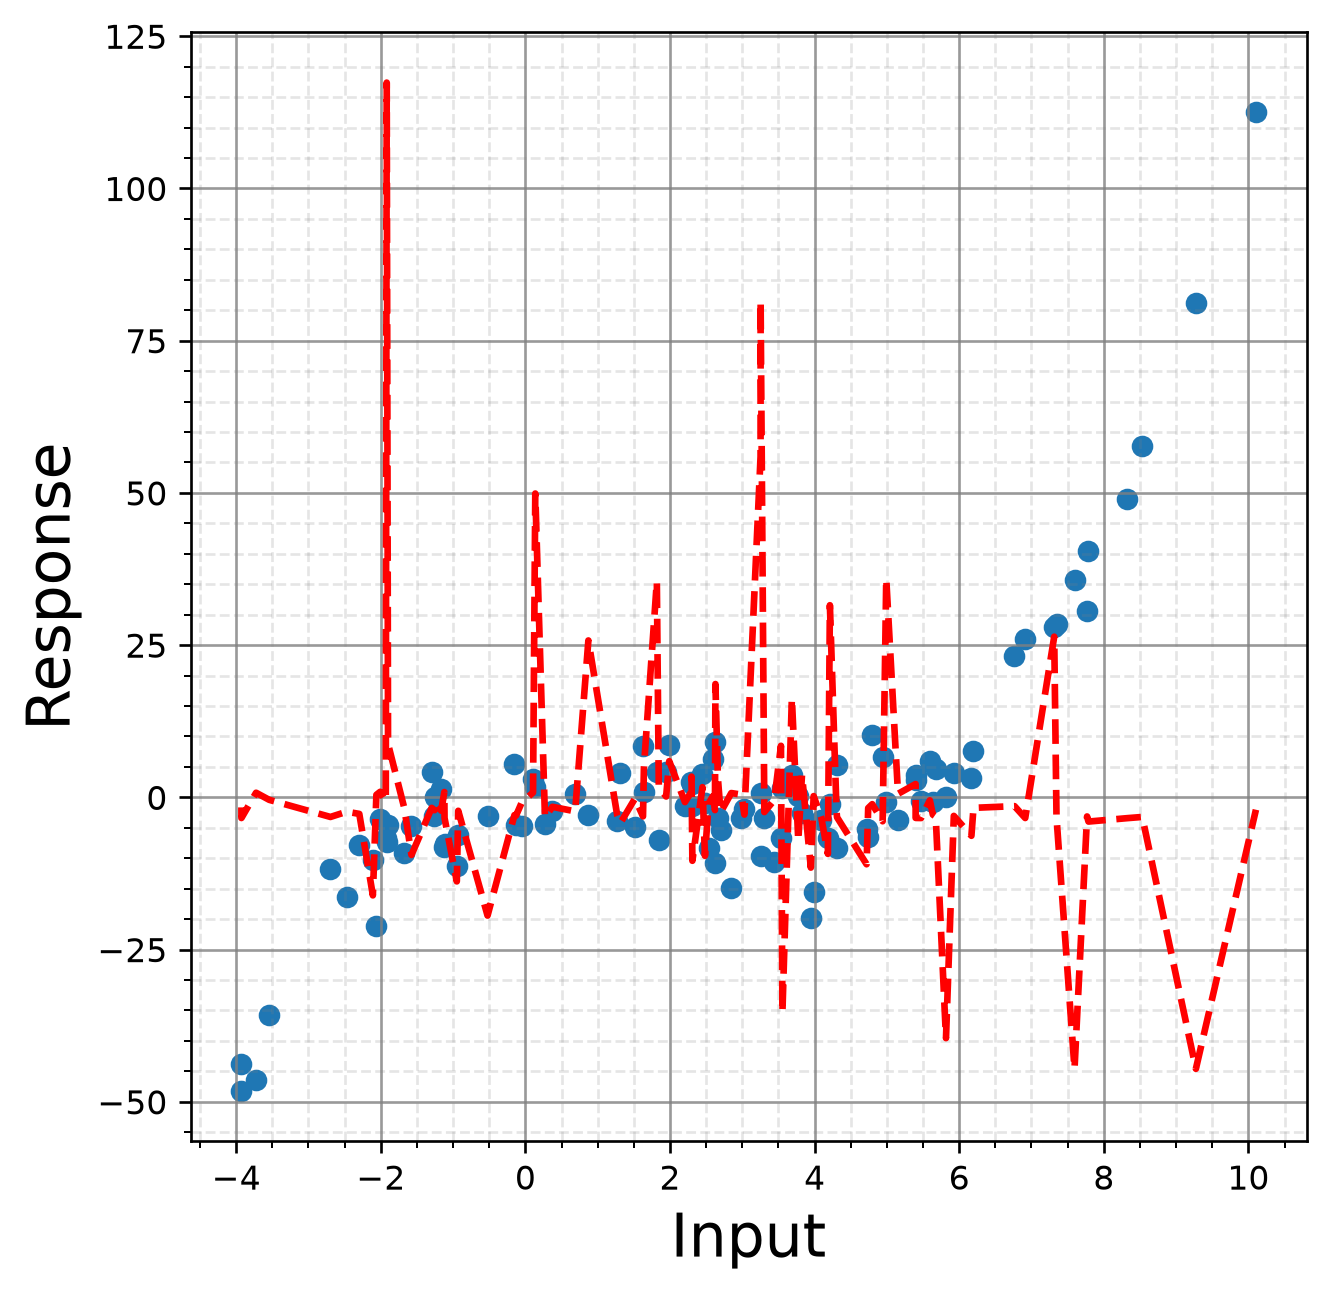

In [121]:
np.random.seed(1693)
x = 2 - 3 * np.random.normal(0, 1, 100)

def f(x):
    sz = len(x)
    return x - 1.5 * (x ** 2) + 0.25 * (x ** 3) + 5 * np.random.normal(loc=0, scale=1, size=sz)

y = f(x)

polynomial_features= PolynomialFeatures(degree=3)
x_poly = polynomial_features.fit_transform(x.reshape((-1,1)))

# the model created is linear in weights
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

rmse = np.sqrt(mean_squared_error(y,y_poly_pred))
r2 = r2_score(y,y_poly_pred)
print(rmse)
print(r2)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x, y, s=30)
# sort the values of x before line plot
sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
x_sorted, y_pred_sorted = zip(*sorted_zip)
ax.plot(x_sorted, y_poly_pred, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Response',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In [ ]:
model.coef_

array([ 0.        ,  1.26204772, -1.59419899,  0.25857094])

In [ ]:
pd.DataFrame(x_poly)

,0,1,2,3,4
0,1.0,4.741352,22.480420,106.587590,505.369302
1,1.0,3.554897,12.637292,44.924268,159.701140
2,1.0,0.105749,0.011183,0.001183,0.000125
3,1.0,1.626725,2.646233,4.304692,7.002549
4,1.0,3.252754,10.580411,34.415480,111.945106
...,...,...,...,...,...
95,1.0,-1.257303,1.580812,-1.987560,2.498966
96,1.0,3.685663,13.584110,50.066446,184.528032
97,1.0,3.253514,10.585350,34.439581,112.049645
98,1.0,-3.928013,15.429287,-60.606442,238.062900


### <font color='red'> Example: a noisy sine wave</font>

In [83]:
x = np.linspace(0,np.pi,150)
epsilon = np.random.normal(scale=0.2,size=x.shape)
y = np.sin(4*x) + epsilon

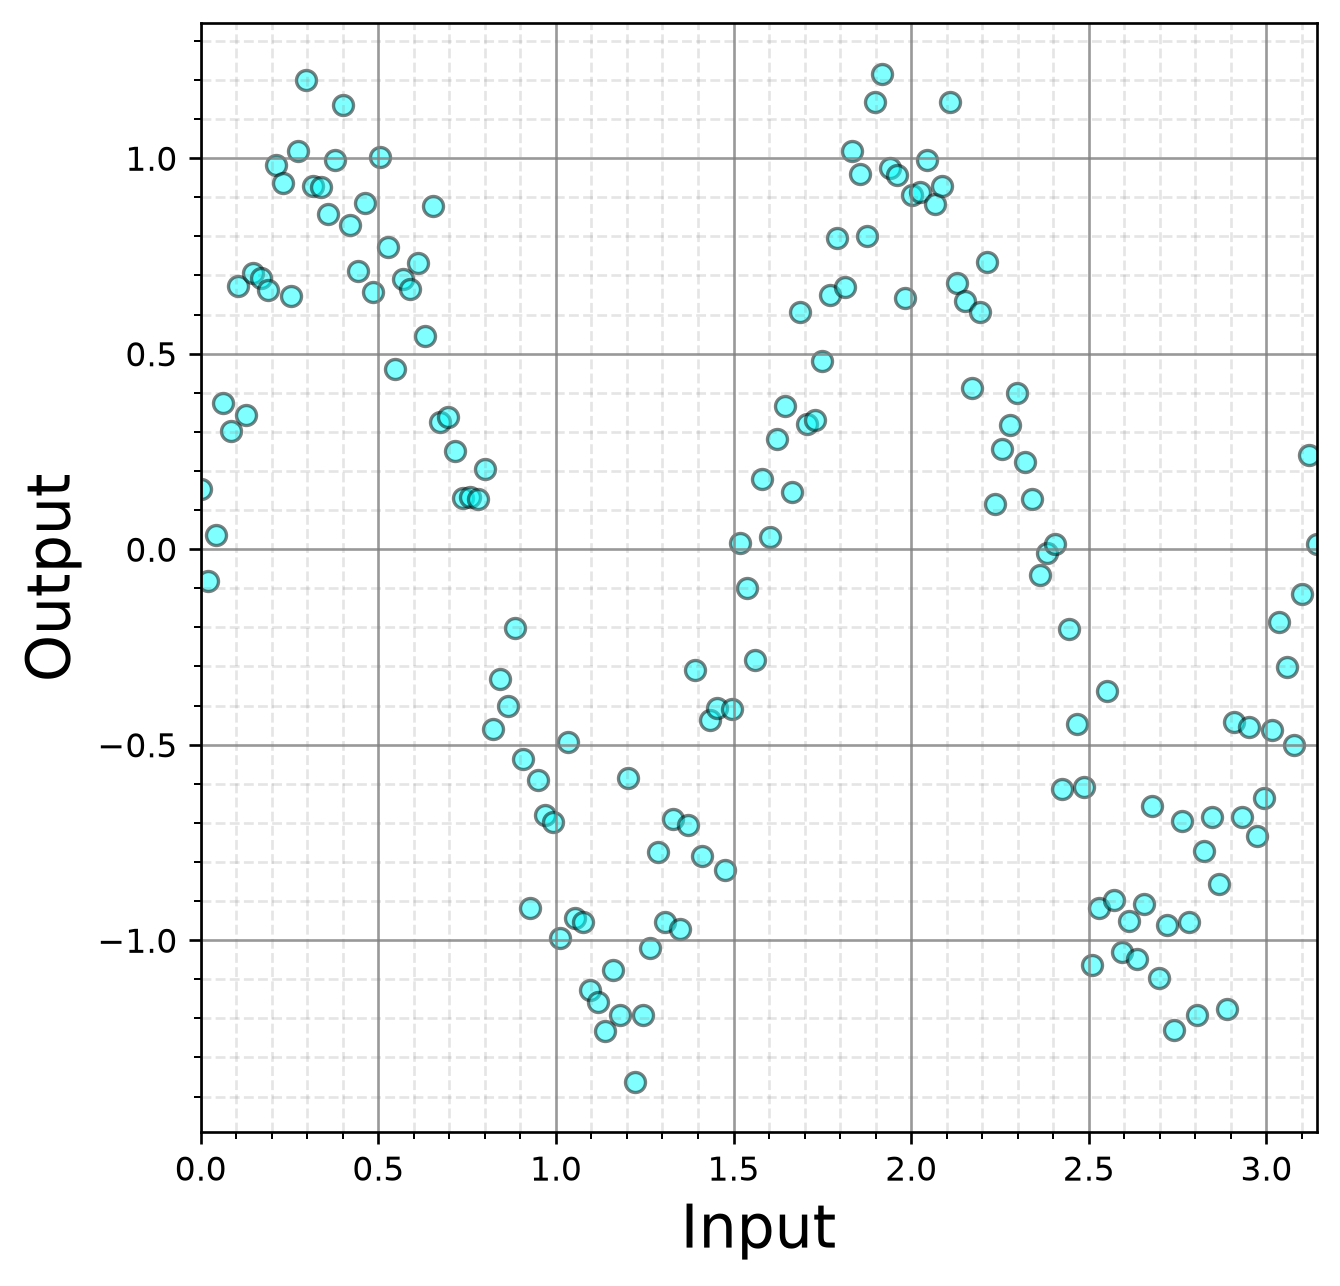

In [86]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6) # here we setup a desired figure size.
ax.scatter(x,y,ec='k',color='cyan',alpha=0.5) # we generate a scatter plot of x and y
ax.set_xlim([0,np.pi]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(visible=True,which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(visible=True,which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In [87]:
# create polynomial features and "guess" the best degree for this example
poly = PolynomialFeatures(degree=7)
xpoly = poly.fit_transform(x.reshape(-1,1))
model = LinearRegression(fit_intercept=False)
model.fit(xpoly,y)
yhat = model.predict(xpoly)

The R2 coefficient of determination is : 0.9325279467537726


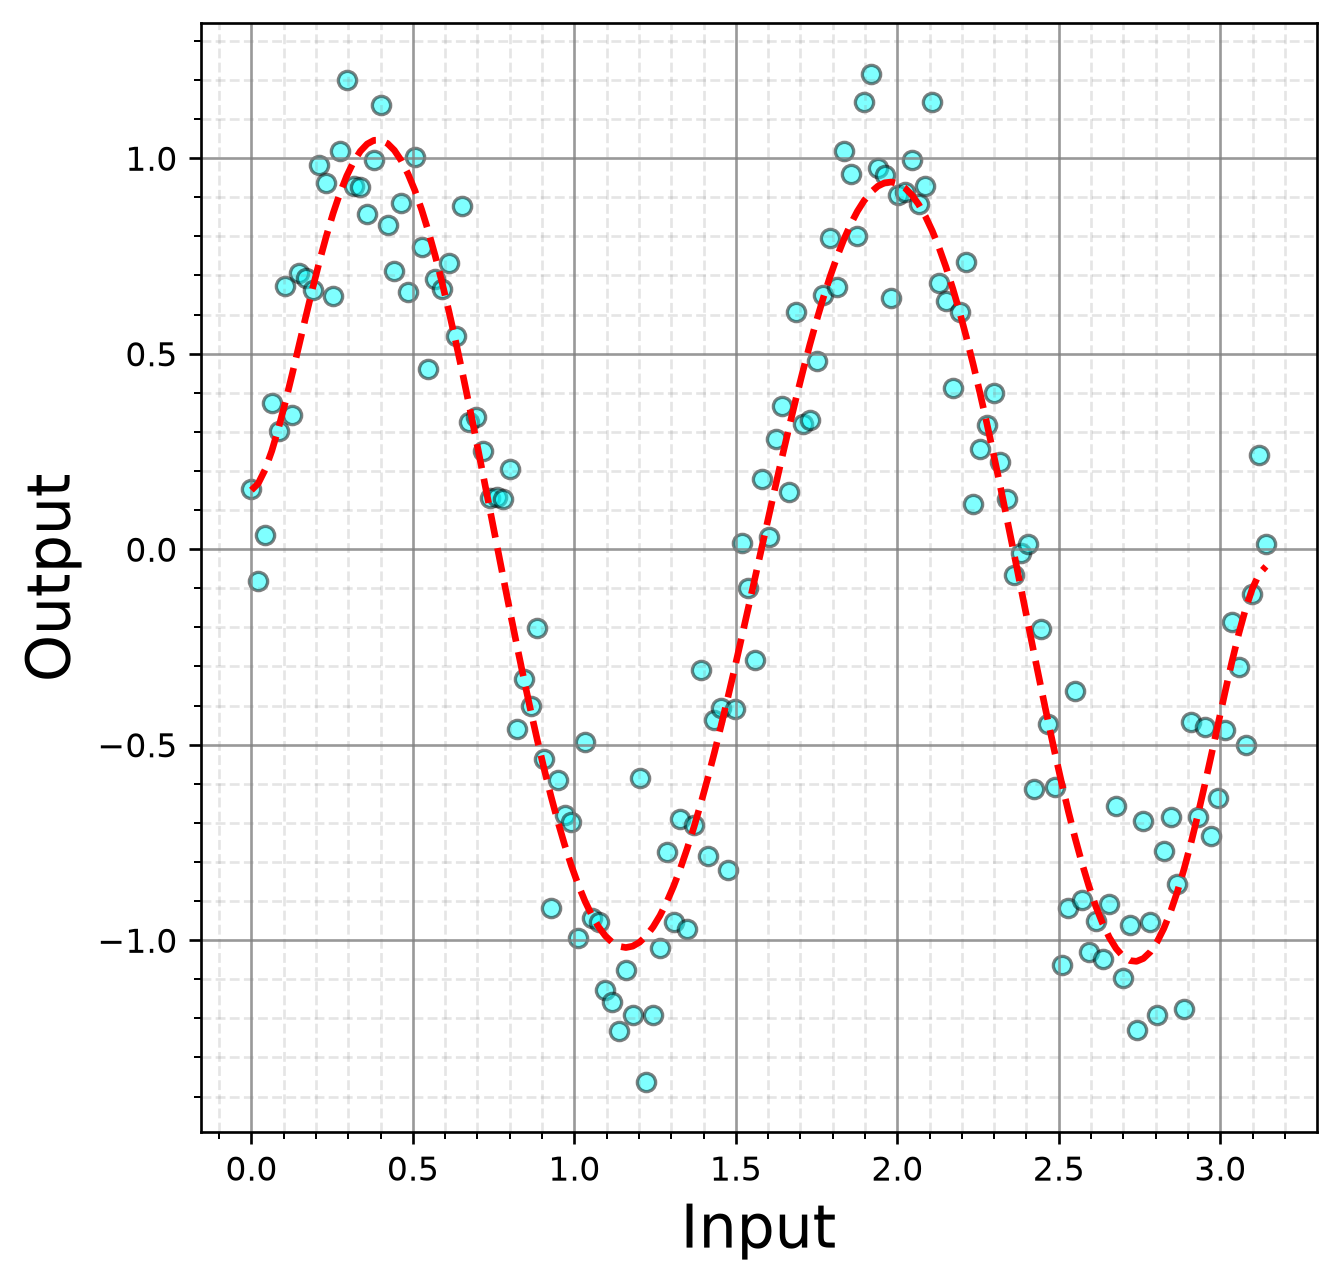

In [89]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6)
ax.scatter(x, y, s=30,ec='k',color='cyan',alpha=0.5)
# sort the values of x before line plot
ax.plot(x, yhat, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(visible=True,which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(visible=True,which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
print('The R2 coefficient of determination is : ' +str(model.score(xpoly,y)))
plt.show()

### Polynomial models with two or more variables

In [95]:
cars.head(3)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


In [96]:
X = cars[['cyl','wt']]

In [97]:
scale = StandardScaler()
X = pd.DataFrame(data=scale.fit_transform(X), columns=X.columns)

In [99]:
X.head(3)

,cyl,wt
0,-0.106668,-0.620167
1,-0.106668,-0.355382
2,-1.244457,-0.931678


In [100]:
def PolynomialFeatures_labeled(input_df,power):
    '''Basically this is a cover for the sklearn preprocessing function.
    The problem with that function is if you give it a labeled dataframe, it ouputs an unlabeled dataframe with potentially
    a whole bunch of unlabeled columns.
    Inputs:
    input_df = Your labeled pandas dataframe (list of x's not raised to any power)
    power = what order polynomial you want variables up to. (use the same power as you want entered into pp.PolynomialFeatures(power) directly)
    Ouput:
    Output: This function relies on the powers_ matrix which is one of the preprocessing function's outputs to create logical labels and
    outputs a labeled pandas dataframe
    https://gist.github.com/michaelguia/a87d76eb6722a90893f375bff87260f7
    '''
    poly = PolynomialFeatures(power)
    output_nparray = poly.fit_transform(input_df)
    powers_nparray = poly.powers_

    input_feature_names = list(input_df.columns)
    target_feature_names = ["Constant Term"]
    for feature_distillation in powers_nparray[1:]:
        intermediary_label = ""
        final_label = ""
        for i in range(len(input_feature_names)):
            if feature_distillation[i] == 0:
                continue
            else:
                variable = input_feature_names[i]
                power = feature_distillation[i]
                intermediary_label = "%s^%d" % (variable,power)
                if final_label == "":         #If the final label isn't yet specified
                    final_label = intermediary_label
                else:
                    final_label = final_label + " * " + intermediary_label
        target_feature_names.append(final_label)
    output_df = pd.DataFrame(output_nparray, columns = target_feature_names)
    return output_df

In [101]:
df = PolynomialFeatures_labeled(X,6)

In [102]:
len(df.columns)

28

In [106]:
dist = getattr(stats, 'norm')
params = dist.fit(residuals)

In [107]:
params

(np.float64(-8.215650382226158e-15), np.float64(2.949162685955028))

In [108]:
# here we apply the test
stats.kstest(residuals, "norm", params)

KstestResult(statistic=np.float64(0.08217402470387336), pvalue=np.float64(0.9698176646662029), statistic_location=np.float64(-1.8830236224503238), statistic_sign=np.int8(1))

#### The conclusion, in our case, we do not find sufficient evidence to reject the normality assumption.

In [111]:
from scipy.stats import ksone

In [112]:
# for your convenience, this is the table with the critical values for the
# Kolmogorov-Smirnov test

def ks_critical_value(n_trials, alpha):
    return ksone.ppf(1-alpha/2, n_trials)

trials = range(1, 40)
alphas = [0.1, 0.05, 0.02, 0.01]

# Print table headers
print('{:<6}|{:<6} Level of significance, alpha'.format(' ', ' '))
print('{:<6}|{:>8} {:>8} {:>8} {:>8}'.format(*['Trials'] + alphas))
print('-' * 42)
# Print critical values for each n_trials x alpha combination
for t in trials:
    print('{:6d}|{:>8.5f} {:>8.5f} {:>8.5f} {:>8.5f}'
          .format(*[t] + [ks_critical_value(t, a) for a in alphas]))
    if t % 10 == 0:
        print()

      |       Level of significance, alpha
Trials|     0.1     0.05     0.02     0.01
------------------------------------------
     1| 0.95000  0.97500  0.99000  0.99500
     2| 0.77639  0.84189  0.90000  0.92929
     3| 0.63604  0.70760  0.78456  0.82900
     4| 0.56522  0.62394  0.68887  0.73424
     5| 0.50945  0.56328  0.62718  0.66853
     6| 0.46799  0.51926  0.57741  0.61661
     7| 0.43607  0.48342  0.53844  0.57581
     8| 0.40962  0.45427  0.50654  0.54179
     9| 0.38746  0.43001  0.47960  0.51332
    10| 0.36866  0.40925  0.45662  0.48893

    11| 0.35242  0.39122  0.43670  0.46770
    12| 0.33815  0.37543  0.41918  0.44905
    13| 0.32549  0.36143  0.40362  0.43247
    14| 0.31417  0.34890  0.38970  0.41762
    15| 0.30397  0.33760  0.37713  0.40420
    16| 0.29472  0.32733  0.36571  0.39201
    17| 0.28627  0.31796  0.35528  0.38086
    18| 0.27851  0.30936  0.34569  0.37062
    19| 0.27136  0.30143  0.33685  0.36117
    20| 0.26473  0.29408  0.32866  0.35241

    21| 0

In [113]:
ks_critical_value(31,0.4)

np.float64(0.15594527177147208)

#### A different normality test indicates the same thing

In [ ]:
stats.anderson(residuals,dist='norm')

AndersonResult(statistic=0.46842144463906266, critical_values=array([0.523, 0.596, 0.715, 0.834, 0.992]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]))

In [ ]:
stats.shapiro(residuals)

(0.9450768828392029, 0.10438867658376694)

In [ ]:
#@title
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

In [ ]:
x = cars.iloc[:,2:8]
x

,cyl,disp,hp,drat,wt,qsec
0,6,160.0,110,3.90,2.620,16.46
1,6,160.0,110,3.90,2.875,17.02
2,4,108.0,93,3.85,2.320,18.61
3,6,258.0,110,3.08,3.215,19.44
4,8,360.0,175,3.15,3.440,17.02
5,6,225.0,105,2.76,3.460,20.22
6,8,360.0,245,3.21,3.570,15.84
7,4,146.7,62,3.69,3.190,20.00
8,4,140.8,95,3.92,3.150,22.90
9,6,167.6,123,3.92,3.440,18.30


In [ ]:
model.fit(x,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
model.score(x,y)

0.8548224115848234

In [ ]:
residuals = y - model.predict(x)

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


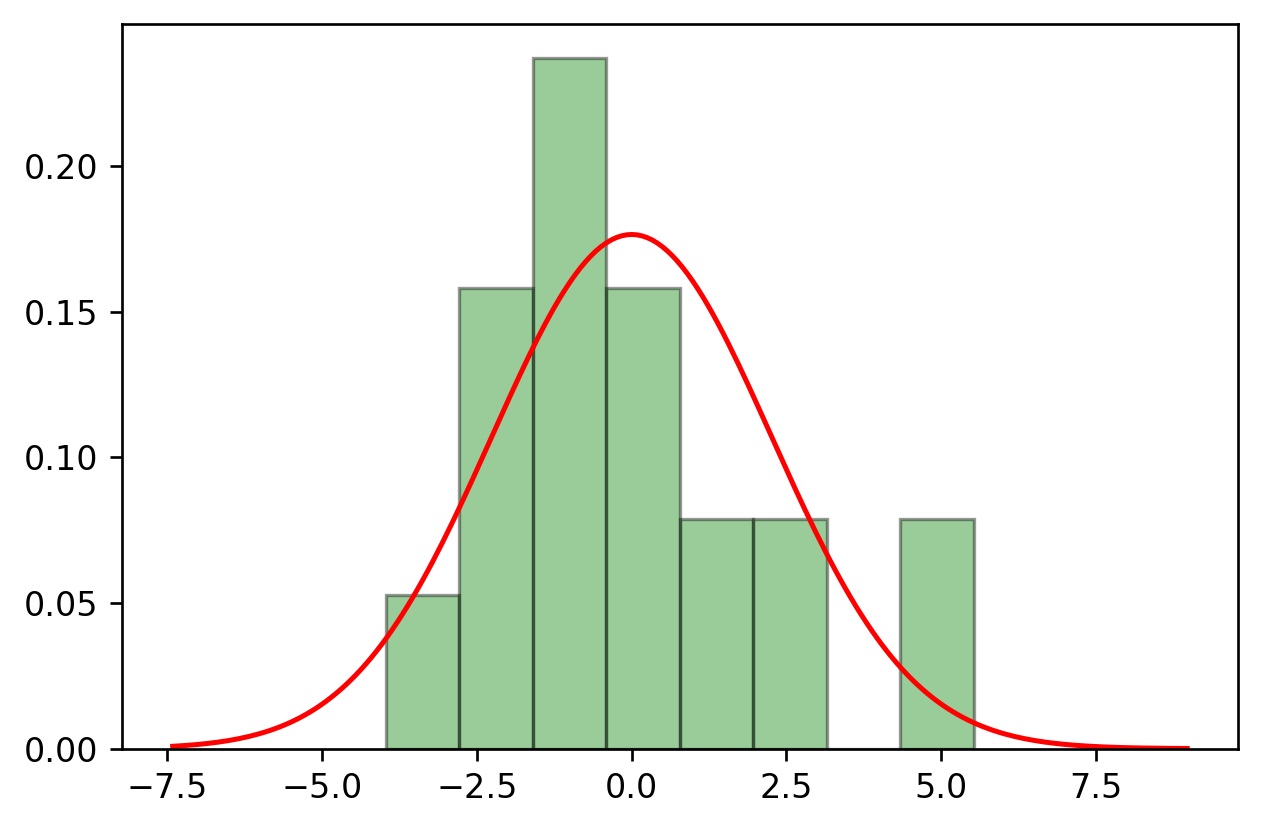

In [ ]:

sns.distplot(residuals,
                  bins=8,
                  kde=False,
                  color='deepskyblue',
                  hist_kws={"color":'green','ec':'black'},
                  fit=stats.norm,
                  fit_kws={"color":'red'})
plt.show()

In [ ]:
dist = getattr(stats, 'norm')
params = dist.fit(residuals)

In [ ]:
# here we apply the Kolmogorov-Smirnov test
stats.kstest(residuals, "norm", params) # the confidence has increased compared to the case of using only one input feature.

KstestResult(statistic=0.15722261669146254, pvalue=0.37091468826166857)

# <font color='blue'>Summary: Regression Modeling Pipeline</font>

### <font color='green'>1. Define the Problem</font>

Choose the input features $X$ and continuous output $y$:

$$
X \longrightarrow y
$$

### <font color='green'>2. Choose a Model</font>

Examples:

$$
\text{Linear:}\qquad
\hat y=w_0+w_1x
$$

$$
\text{Polynomial:}\qquad
\hat y=w_0+w_1x+w_2x^2+\cdots+w_px^p
$$

Both are **linear in their weights**.

### <font color='green'>3. Learn the Weights</font>

OLS minimizes the squared residuals:

$$
\boxed{
\hat{\mathbf w}
=
\arg\min_{\mathbf w}
\sum_{i=1}^n(y_i-\hat y_i)^2
}
$$

The optimum can be found analytically for linear models or iteratively using **Gradient Descent**.

### <font color='green'>4. Evaluate the Model</font>

Use prediction-error and goodness-of-fit metrics:

$$
\boxed{\text{MSE},\quad \text{RMSE},\quad \text{MAE},\quad R^2}
$$

and examine the **residuals**:

$$
e_i=y_i-\hat y_i.
$$

### <font color='green'>5. Check Generalization (leave for later lectures)</font>

A model that fits the training data extremely well may still **overfit**.

$$
\boxed{
\text{Train Model}
\rightarrow
\text{Evaluate on Unseen Data}
\rightarrow
\text{Select Model}
}
$$

<font color='red'>
<b>Critical Thinking:</b> If increasing the polynomial degree improves training $R^2$, should we always choose the highest degree?
</font>
